In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="talk")

plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS",   # macOS 常见，兼容性好
    "PingFang SC",        # macOS
    "Heiti SC",           # macOS
    "SimHei",             # Windows
    "Microsoft YaHei",    # Windows
    "Noto Sans CJK SC",   # Linux
    "WenQuanYi Micro Hei" # Linux
]
plt.rcParams["axes.unicode_minus"] = False  # 防止负号显示成方块

plt.rcParams["figure.dpi"] = 300
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

BASE_DIR = Path.cwd()
if BASE_DIR.name != "src":
    BASE_DIR = BASE_DIR / "src"

SPEARMAN_PATH = BASE_DIR / "result_v1" / "spearman.csv"
FIG_DIR = BASE_DIR / "result_v1" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

spearman_df = pd.read_csv(SPEARMAN_PATH)
METHOD_ORDER = ["EXACT", "BP", "RK", "ABRA", "SILVAN", "GPU_SIR_BRIDGE"]
DISPLAY_METHOD_ORDER = ["Exact", "BP", "RK", "ABRA", "SILVAN", "FastBC"]
METHOD_LABELS = dict(zip(METHOD_ORDER, DISPLAY_METHOD_ORDER))

spearman_df.head()


,graph_name,graph_source,num_nodes,num_edges,epsilon,top_k,top_k_ratio,exact_time,method_x,method_y,spearman
0,Celegans,real,297,2148,0.1,30,0.1,0.186838,EXACT,EXACT,1.000000
1,Celegans,real,297,2148,0.1,30,0.1,0.186838,EXACT,BP,0.649997
2,Celegans,real,297,2148,0.1,30,0.1,0.186838,EXACT,RK,0.805240
3,Celegans,real,297,2148,0.1,30,0.1,0.186838,EXACT,ABRA,0.972233
4,Celegans,real,297,2148,0.1,30,0.1,0.186838,EXACT,SILVAN,0.978692


In [2]:
EPSILON = 0.1

GRAPH_GROUPS = {
    "Real": ["bitcoin-alpha", "wiki-Vote",  "p2p-Gnutella06", "Soc-hamsterster"],
    "BA": ["BA1000", "BA2000", "BA3000", "BA5000"],
    "WS": ["WS1000", "WS2000", "WS3000", "WS5000"],
    "ER": ["ER1000", "ER2000", "ER3000", "ER5000"],
}

GRAPH_SOURCE = {
    "Real": "real",
    "BA": "synthetic",
    "WS": "synthetic",
    "ER": "synthetic",
}

available_real = sorted(spearman_df.loc[spearman_df["graph_source"] == "real", "graph_name"].unique())
available_synthetic = sorted(spearman_df.loc[spearman_df["graph_source"] == "synthetic", "graph_name"].unique())

print("Available real graphs:")
print(available_real)
print()
print("Available synthetic graphs:")
print(available_synthetic)


Available real graphs:
['Celegans', 'Fb-tvshow', 'Router', 'Soc-hamsterster', 'Yeast', 'bitcoin-alpha', 'ca-GrQc', 'cora', 'p2p-Gnutella06', 'wiki-Vote']

Available synthetic graphs:
['BA1000', 'BA10000', 'BA2000', 'BA3000', 'BA5000', 'ER1000', 'ER2000', 'ER3000', 'ER5000', 'WS1000', 'WS2000', 'WS3000', 'WS5000']


Saved figure to: /Users/zhangjuyuan/Documents/projects/FastBC/src/result_v1/figures/spearman_heatmap_grid_4x4.png


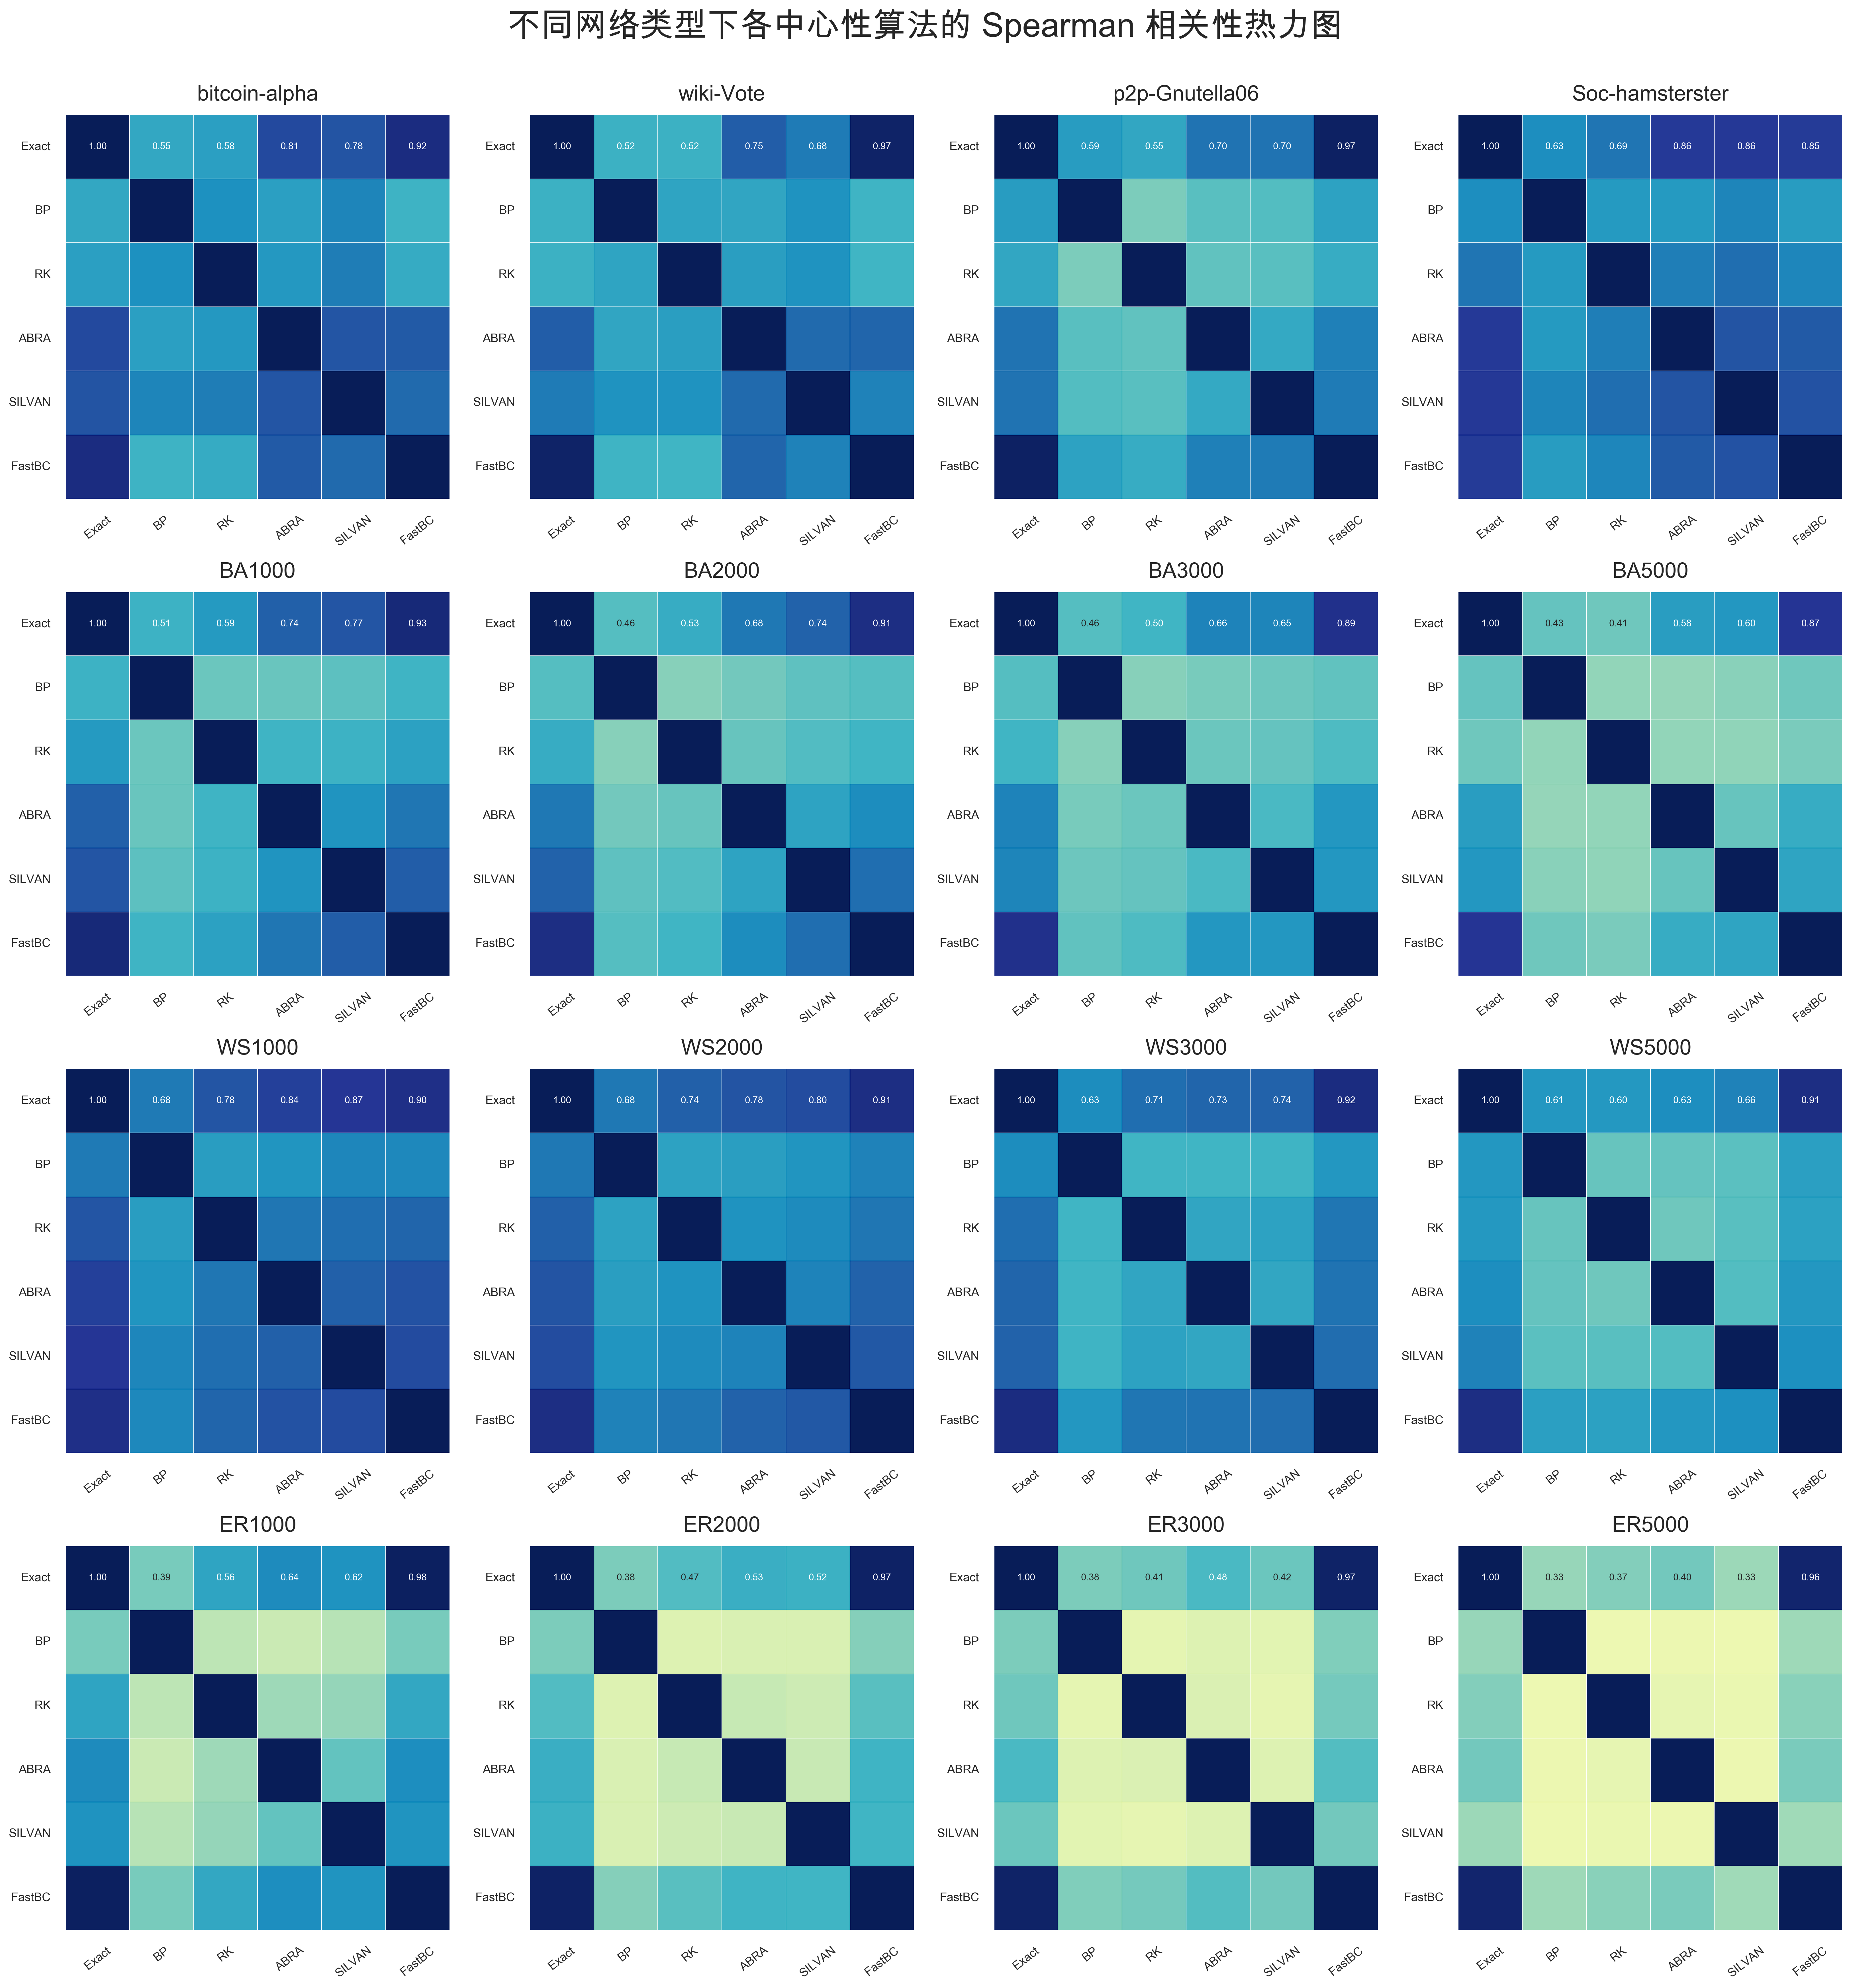

In [3]:
plot_df = spearman_df.loc[spearman_df["epsilon"] == EPSILON].copy()

fig, axes = plt.subplots(4, 4, figsize=(22, 24))
fig.suptitle("不同网络类型下各中心性算法的 Spearman 相关性热力图", fontsize=28, fontweight="bold", y=0.97)

for row_idx, (group_name, graph_names) in enumerate(GRAPH_GROUPS.items()):
    expected_source = GRAPH_SOURCE[group_name]
    for col_idx, graph_name in enumerate(graph_names):
        ax = axes[row_idx, col_idx]
        rows = plot_df.loc[
            (plot_df["graph_source"] == expected_source)
            & (plot_df["graph_name"] == graph_name)
        ]

        if rows.empty:
            ax.set_axis_off()
            ax.text(0.5, 0.5, f"Missing\n{graph_name}", ha="center", va="center", fontsize=16, fontweight="bold")
            continue

        matrix = rows.pivot(index="method_x", columns="method_y", values="spearman")
        matrix = matrix.reindex(index=METHOD_ORDER, columns=METHOD_ORDER)
        matrix = matrix.rename(index=METHOD_LABELS, columns=METHOD_LABELS)

        sns.heatmap(
            matrix,
            ax=ax,
            cmap="YlGnBu",
            vmin=0,
            vmax=1,
            square=True,
            annot=True,
            fmt=".2f",
            annot_kws={"fontsize": 8, "fontweight": "bold"},
            linewidths=0.4,
            linecolor="white",
            cbar=False,
        )
        ax.set_title(graph_name, fontsize=18, fontweight="bold", pad=12)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=38, labelsize=10)
        ax.tick_params(axis="y", rotation=0, labelsize=10)
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight("bold")

plt.tight_layout(rect=[0, 0, 1, 0.97])
save_path = FIG_DIR / "spearman_heatmap_grid_4x4.png"
fig.savefig(save_path, bbox_inches="tight")
print(f"Saved figure to: {save_path}")
plt.show()
